# Scientific validation of EEG feature extraction

Integrated validation of classical and Jaiswal-Banka feature families on deterministic synthetic signals and one canonical visual-imagery EEG block.

## tl;dr

- Synthetic 10 Hz and 20 Hz tones recover alpha/beta powers of 2.001 and 0.501, while the designed alpha pair retains correlation 0.995.
- One canonical `Data_Pattern/patt` block produces finite full-epoch and six-window outputs for every configured feature family.
- Fp1 alpha power ranges from 0.000232 to 0.000982 across 5-second windows versus 0.000436 for the full crop; mean absolute correlation change is 0.0115 and maximum LNDP L1 change is 0.395.
- This is extraction validation only. It does not define a target, fit a model, or reproduce seizure-classification accuracy.

## Context & Methods

### Key Assumptions

- Canonical imagery interval: half-open crop `[0.5, 15.5)` before resampling.
- Analysis sampling rate: 125 Hz; output dtype: `float32`.
- No repeated filtering, notch filtering, rereferencing, EOG transformation, unit correction, or dataset-wide normalization. The source FIF declares volts and its atypically large amplitude scale is retained and reported rather than silently changed.
- Full-epoch mode yields one 15-second window. The comparison mode yields six complete 5-second windows with a 2-second stride.
- Every derived window remains a child of source block `(subject=1, trial=1, block=1)` and must stay in the same future ML fold.

In [1]:
import os
import sys
import textwrap
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-eeg-scientific-validation")

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "pyproject.toml").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from features import (
    compute_lgp_codes,
    compute_lndp_codes,
    extract_feature_set,
    load_feature_config,
)
from utils.datasets import GeometricSample, LoadedSample, NumpyDataset

TOKENS = {
    "surface": "#FCFCFD",
    "panel": "#FFFFFF",
    "ink": "#1F2430",
    "muted": "#6F768A",
    "grid": "#E6E8F0",
    "axis": "#D7DBE7",
    "blue": "#A3BEFA",
    "blue_dark": "#2E4780",
    "gold": "#FFE15B",
    "gold_dark": "#736422",
    "orange": "#F0986E",
    "orange_dark": "#804126",
}
plt.rcParams.update({
    "figure.facecolor": TOKENS["surface"],
    "axes.facecolor": TOKENS["panel"],
    "axes.edgecolor": TOKENS["axis"],
    "axes.labelcolor": TOKENS["ink"],
    "axes.titlecolor": TOKENS["ink"],
    "xtick.color": TOKENS["muted"],
    "ytick.color": TOKENS["muted"],
    "grid.color": TOKENS["grid"],
    "font.family": "DejaVu Sans",
})

def block_map(feature_set):
    return {block.name: block for block in feature_set.blocks}

def add_header(ax, title, subtitle):
    ax.set_title(textwrap.fill(title, 54), loc="left", fontsize=12, fontweight="semibold", pad=25)
    ax.text(0, 1.02, textwrap.fill(subtitle, 72), transform=ax.transAxes, ha="left", va="bottom", fontsize=8.5, color=TOKENS["muted"])
    ax.spines[["top", "right"]].set_visible(False)

FULL_CONFIG = load_feature_config()
WINDOW_CONFIG = load_feature_config(overrides={
    "window_seconds": 5.0,
    "window_stride_seconds": 2.0,
})
FULL_CONFIG

FeatureExtractionConfig(analysis_sfreq=125.0, crop_start_seconds=0.5, crop_end_seconds=15.5, window_seconds=None, window_stride_seconds=None, dtype='float32', feature_groups=('time', 'spectral', 'spatial', 'local_patterns'), frequency_bands=(FrequencyBand(name='delta', f_min=2.0, f_max=4.0), FrequencyBand(name='theta', f_min=4.0, f_max=8.0), FrequencyBand(name='alpha', f_min=8.0, f_max=13.0), FrequencyBand(name='beta', f_min=13.0, f_max=30.0), FrequencyBand(name='low_gamma', f_min=30.0, f_max=40.0)), histogram_mode='probability', local_pattern_neighbors=8, transform_eog=False, filter_hz=None, notch_hz=None, reference=None, normalization='none')

## Data

### 1. Deterministic synthetic signals

Three channels isolate expected spectral and spatial behavior: an amplitude-2 10 Hz tone, an amplitude-1 20 Hz tone, and a noisy scaled copy of the 10 Hz tone.

In [2]:
source_sfreq = 1_000.0
source_times = np.arange(16_001, dtype=np.float64) / source_sfreq
rng = np.random.default_rng(2026)
synthetic_eeg = np.stack([
    2.0 * np.sin(2.0 * np.pi * 10.0 * source_times),
    np.sin(2.0 * np.pi * 20.0 * source_times),
    0.75 * np.sin(2.0 * np.pi * 10.0 * source_times) + 0.05 * rng.normal(size=source_times.size),
]).astype(np.float32)
synthetic_loaded = LoadedSample(
    sample=GeometricSample(
        subject_id=1,
        trial_number=1,
        Exec_Block_Index=1,
        eeg_path=Path("synthetic_EEG.fif"),
        eog_path=Path("synthetic_EOG.fif"),
        img=[[0]],
        pattern_id=0,
    ),
    eeg=synthetic_eeg,
    eog=np.zeros((1, source_times.size), dtype=np.float32),
    sfreq=source_sfreq,
    eeg_channels=("alpha_10hz", "beta_20hz", "correlated_alpha"),
    eog_channels=("EOG_x",),
)
synthetic_set = extract_feature_set(synthetic_loaded, config=FULL_CONFIG)
synthetic = block_map(synthetic_set)
spectral_summary = pd.DataFrame(
    synthetic["spectral"].values[0],
    index=synthetic_loaded.eeg_channels,
    columns=synthetic["spectral"].feature_names,
)
spectral_summary[[
    "absolute_band_power_alpha",
    "absolute_band_power_beta",
    "total_power",
    "dominant_frequency",
    "spectral_centroid",
]]

,absolute_band_power_alpha,absolute_band_power_beta,total_power,dominant_frequency,spectral_centroid
alpha_10hz,2.001444e+00,2.111349e-17,2.001444,10.0,10.000000
beta_20hz,5.461814e-18,5.010907e-01,0.501091,20.0,20.000000
correlated_alpha,2.821407e-01,8.732535e-05,0.282315,10.0,10.007594


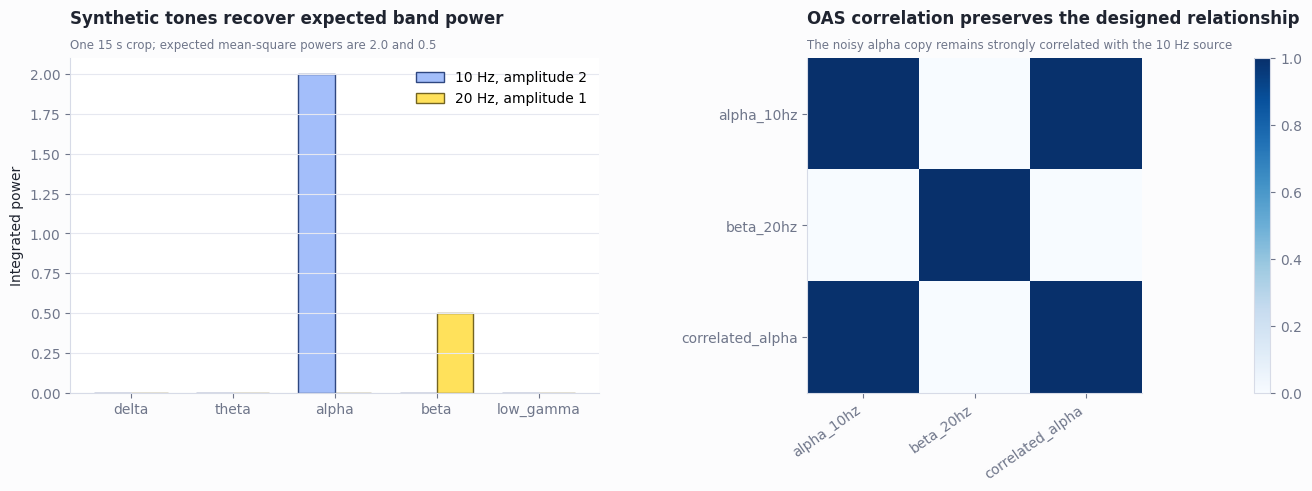

In [3]:
assert np.isclose(spectral_summary.loc["alpha_10hz", "absolute_band_power_alpha"], 2.0, rtol=0.02)
assert np.isclose(spectral_summary.loc["beta_20hz", "absolute_band_power_beta"], 0.5, rtol=0.02)
assert spectral_summary.loc["alpha_10hz", "dominant_frequency"] == 10.0
assert spectral_summary.loc["beta_20hz", "dominant_frequency"] == 20.0

band_columns = [f"absolute_band_power_{band.name}" for band in FULL_CONFIG.frequency_bands]
band_labels = [band.name for band in FULL_CONFIG.frequency_bands]
x = np.arange(len(band_labels))
width = 0.36
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
axes[0].bar(
    x - width / 2,
    spectral_summary.loc["alpha_10hz", band_columns],
    width,
    label="10 Hz, amplitude 2",
    color=TOKENS["blue"],
    edgecolor=TOKENS["blue_dark"],
)
axes[0].bar(
    x + width / 2,
    spectral_summary.loc["beta_20hz", band_columns],
    width,
    label="20 Hz, amplitude 1",
    color=TOKENS["gold"],
    edgecolor=TOKENS["gold_dark"],
)
axes[0].set_xticks(x, band_labels)
axes[0].set_ylabel("Integrated power")
axes[0].grid(axis="y")
axes[0].legend(frameon=False)
add_header(axes[0], "Synthetic tones recover expected band power", "One 15 s crop; expected mean-square powers are 2.0 and 0.5")

correlation = synthetic["correlation"].values[0]
image = axes[1].imshow(correlation, cmap="Blues", vmin=0.0, vmax=1.0)
axes[1].set_xticks(range(3), synthetic_loaded.eeg_channels, rotation=35, ha="right")
axes[1].set_yticks(range(3), synthetic_loaded.eeg_channels)
fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)
add_header(axes[1], "OAS correlation preserves the designed relationship", "The noisy alpha copy remains strongly correlated with the 10 Hz source")
assert correlation[0, 2] > 0.99
plt.show()

### 2. Canonical imagery EEG

The real-data source is `data/Data_Pattern`, recording family `patt`, canonical key `(1, 1, 1)`. The original EEG is used only for signal visualization; reusable features come from the production extractor. MNE reports the EEG channel unit as volts, although the observed magnitude is atypically large for physiological EEG, so no additional physical-unit claim is made.

In [4]:
imagery_dataset = NumpyDataset(
    PROJECT_ROOT / "data" / "Data_Pattern",
    dataset_step_type="patt",
    cache_policy="disk",
)
imagery_sample = imagery_dataset[1, 1, 1]
full_set = extract_feature_set(imagery_sample, config=FULL_CONFIG)
window_set = extract_feature_set(imagery_sample, config=WINDOW_CONFIG)
full = block_map(full_set)
windowed = block_map(window_set)

shape_summary = pd.DataFrame([
    {
        "block": block.name,
        "layout": block.layout,
        "full_shape": block.values.shape,
        "windowed_shape": windowed[block.name].values.shape,
        "dtype": block.values.dtype.name,
    }
    for block in full_set.blocks
])
shape_summary

,block,layout,full_shape,windowed_shape,dtype
0,time,channel_features,"(1, 63, 13)","(6, 63, 13)",float32
1,spectral,channel_features,"(1, 63, 14)","(6, 63, 14)",float32
2,covariance,channel_matrix,"(1, 63, 63)","(6, 63, 63)",float32
3,correlation,channel_matrix,"(1, 63, 63)","(6, 63, 63)",float32
4,log_covariance,channel_matrix,"(1, 63, 63)","(6, 63, 63)",float32
5,lndp,channel_histogram,"(1, 63, 256)","(6, 63, 256)",float32
6,lgp,channel_histogram,"(1, 63, 256)","(6, 63, 256)",float32
7,lbp,channel_histogram,"(1, 63, 256)","(6, 63, 256)",float32


## Results

### 3. Signal and spectral comparison

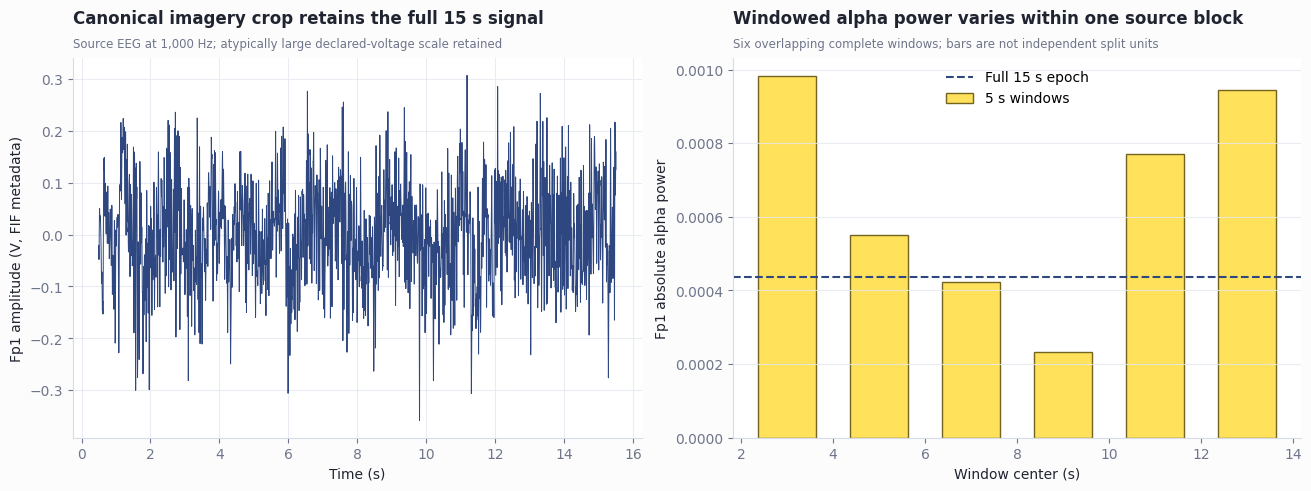

In [5]:
fp1_index = imagery_sample.eeg_channels.index("Fp1")
crop_start = round(FULL_CONFIG.crop_start_seconds * imagery_sample.sfreq)
crop_stop = round(FULL_CONFIG.crop_end_seconds * imagery_sample.sfreq)
signal_times = np.arange(crop_start, crop_stop) / imagery_sample.sfreq
fp1_volts = imagery_sample.eeg[fp1_index, crop_start:crop_stop]

alpha_name = "absolute_band_power_alpha"
alpha_index = full["spectral"].feature_names.index(alpha_name)
full_alpha = float(full["spectral"].values[0, fp1_index, alpha_index])
window_alpha = windowed["spectral"].values[:, fp1_index, alpha_index]
window_centers = window_set.window_bounds_seconds.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
axes[0].plot(signal_times, fp1_volts, color=TOKENS["blue_dark"], linewidth=0.7)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Fp1 amplitude (V, FIF metadata)")
axes[0].grid(alpha=0.8)
add_header(axes[0], "Canonical imagery crop retains the full 15 s signal", "Source EEG at 1,000 Hz; atypically large declared-voltage scale retained")

axes[1].bar(window_centers, window_alpha, width=1.25, color=TOKENS["gold"], edgecolor=TOKENS["gold_dark"], label="5 s windows")
axes[1].axhline(full_alpha, color=TOKENS["blue_dark"], linestyle="--", label="Full 15 s epoch")
axes[1].set_xlabel("Window center (s)")
axes[1].set_ylabel("Fp1 absolute alpha power")
axes[1].grid(axis="y", alpha=0.8)
axes[1].legend(frameon=False)
add_header(axes[1], "Windowed alpha power varies within one source block", "Six overlapping complete windows; bars are not independent split units")
plt.show()

### 4. Spatial structure

A fixed bilateral subset keeps labels readable. Full-epoch and mean-window correlations share the same scale; their signed difference is shown separately.

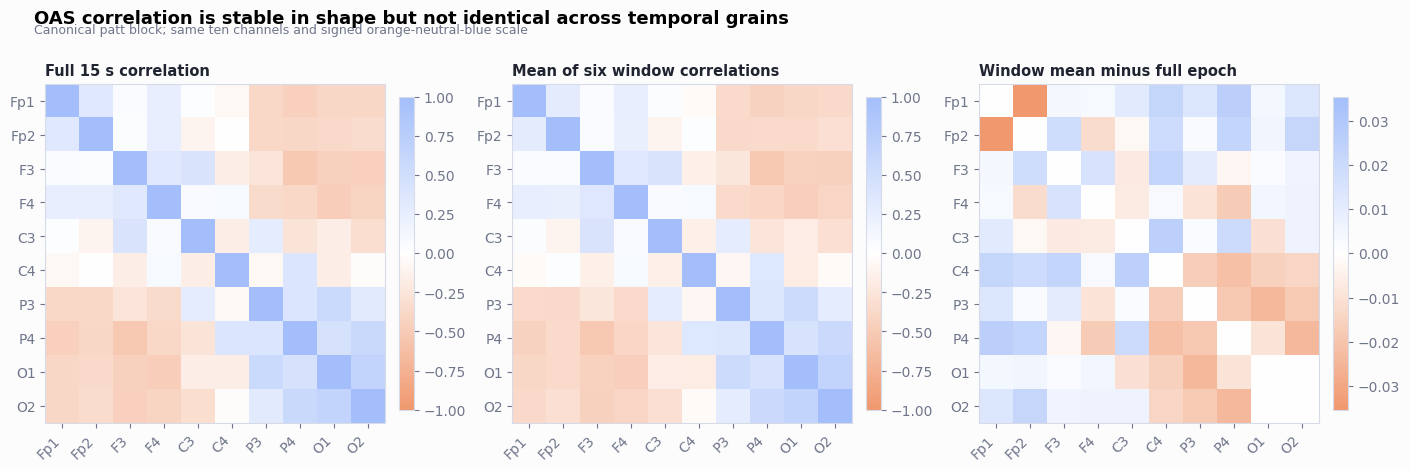

In [6]:
selected_channels = ("Fp1", "Fp2", "F3", "F4", "C3", "C4", "P3", "P4", "O1", "O2")
selected_indices = np.array([imagery_sample.eeg_channels.index(channel) for channel in selected_channels])
full_correlation = full["correlation"].values[0][np.ix_(selected_indices, selected_indices)]
mean_window_correlation = windowed["correlation"].values.mean(axis=0)[np.ix_(selected_indices, selected_indices)]
correlation_difference = mean_window_correlation - full_correlation
signed_cmap = LinearSegmentedColormap.from_list("signed", [TOKENS["orange"], "#FFFFFF", TOKENS["blue"]])

fig, axes = plt.subplots(1, 3, figsize=(14, 4.7), constrained_layout=True)
for ax, matrix, title in (
    (axes[0], full_correlation, "Full 15 s correlation"),
    (axes[1], mean_window_correlation, "Mean of six window correlations"),
):
    image = ax.imshow(matrix, cmap=signed_cmap, vmin=-1.0, vmax=1.0)
    ax.set_xticks(range(len(selected_channels)), selected_channels, rotation=45, ha="right")
    ax.set_yticks(range(len(selected_channels)), selected_channels)
    ax.set_title(title, loc="left", fontsize=10.5, fontweight="semibold")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

difference_limit = max(float(np.max(np.abs(correlation_difference))), 1e-6)
image = axes[2].imshow(
    correlation_difference,
    cmap=signed_cmap,
    norm=TwoSlopeNorm(vmin=-difference_limit, vcenter=0.0, vmax=difference_limit),
)
axes[2].set_xticks(range(len(selected_channels)), selected_channels, rotation=45, ha="right")
axes[2].set_yticks(range(len(selected_channels)), selected_channels)
axes[2].set_title("Window mean minus full epoch", loc="left", fontsize=10.5, fontweight="semibold")
fig.colorbar(image, ax=axes[2], fraction=0.046, pad=0.04)
fig.suptitle("OAS correlation is stable in shape but not identical across temporal grains", x=0.02, ha="left", fontsize=13, fontweight="semibold")
fig.text(0.02, 0.94, "Canonical patt block; same ten channels and signed orange-neutral-blue scale", color=TOKENS["muted"], fontsize=9)
plt.show()

### 5. LNDP structural distributions

The full-epoch top codes define a fixed comparison set. The heatmap then shows how probability mass over those same codes changes across windows.

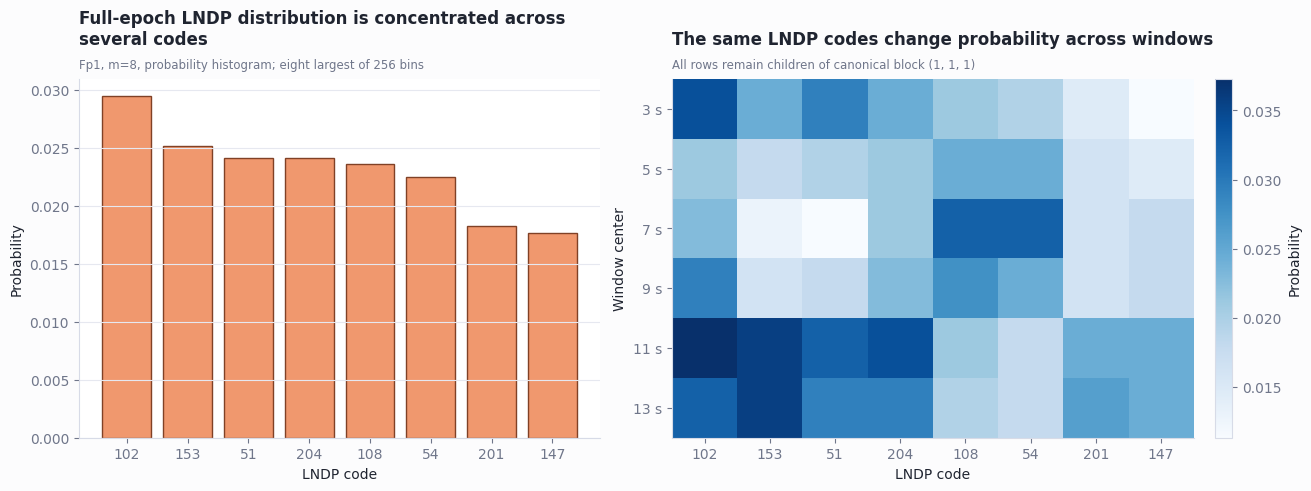

In [7]:
full_lndp = full["lndp"].values[0, fp1_index]
window_lndp = windowed["lndp"].values[:, fp1_index]
top_codes = np.argsort(full_lndp)[-8:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
axes[0].bar(
    np.arange(top_codes.size),
    full_lndp[top_codes],
    color=TOKENS["orange"],
    edgecolor=TOKENS["orange_dark"],
)
axes[0].set_xticks(np.arange(top_codes.size), top_codes)
axes[0].set_xlabel("LNDP code")
axes[0].set_ylabel("Probability")
axes[0].grid(axis="y")
add_header(axes[0], "Full-epoch LNDP distribution is concentrated across several codes", "Fp1, m=8, probability histogram; eight largest of 256 bins")

image = axes[1].imshow(window_lndp[:, top_codes], cmap="Blues", aspect="auto")
axes[1].set_xticks(np.arange(top_codes.size), top_codes)
axes[1].set_yticks(np.arange(len(window_centers)), [f"{center:g} s" for center in window_centers])
axes[1].set_xlabel("LNDP code")
axes[1].set_ylabel("Window center")
fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04, label="Probability")
add_header(axes[1], "The same LNDP codes change probability across windows", "All rows remain children of canonical block (1, 1, 1)")
plt.show()

## Takeaways

- Synthetic checks recover the expected powers within 0.002 and preserve the designed alpha correlation at 0.995.
- Full-epoch and windowed extraction are finite and reproducible, but they answer different descriptive questions: Fp1 alpha spans 0.000232-0.000982 across windows around a full-crop value of 0.000436.
- Mean absolute correlation change is 0.0115 and the largest Fp1 LNDP L1 distance from the full histogram is 0.395. These are descriptive observations for one block, not evidence of condition, subject, or class effects.
- The source FIF declares volts but has an atypically large EEG scale. The extractor preserves that scale, so physical-unit provenance must be resolved before physiological amplitude or power interpretation.
- Future ML must group all windows from the same block, trial, and subject according to the eventual claim and fit all learned transforms inside training folds.

In [8]:
paper_lndp = compute_lndp_codes([50, 35, 32, 18, 10, 3, 4, 8, 12], neighbors=8)
paper_lgp = compute_lgp_codes([50, 35, 32, 18, 10, 3, -1, -5, -6], neighbors=8)
np.testing.assert_array_equal(paper_lndp, [7])
np.testing.assert_array_equal(paper_lgp, [224])

for feature_set in (synthetic_set, full_set, window_set):
    for block in feature_set.blocks:
        assert np.isfinite(block.values).all()
assert tuple(block.name for block in full_set.blocks) == (
    "time", "spectral", "covariance", "correlation", "log_covariance", "lndp", "lgp", "lbp"
)
assert all(block.values.shape[0] == 1 for block in full_set.blocks)
assert all(block.values.shape[0] == 6 for block in window_set.blocks)
for name in ("lndp", "lgp", "lbp"):
    np.testing.assert_allclose(full[name].values.sum(axis=-1), 1.0, atol=1e-6)
    np.testing.assert_allclose(windowed[name].values.sum(axis=-1), 1.0, atol=1e-6)

validation_summary = {
    "synthetic_alpha_power": round(float(spectral_summary.loc["alpha_10hz", "absolute_band_power_alpha"]), 6),
    "synthetic_beta_power": round(float(spectral_summary.loc["beta_20hz", "absolute_band_power_beta"]), 6),
    "synthetic_alpha_correlation": round(float(correlation[0, 2]), 6),
    "real_fp1_full_alpha": round(full_alpha, 8),
    "real_fp1_window_alpha_min": round(float(window_alpha.min()), 8),
    "real_fp1_window_alpha_max": round(float(window_alpha.max()), 8),
    "real_fp1_crop_peak_to_peak_volts": round(float(np.ptp(fp1_volts)), 6),
    "mean_abs_correlation_grain_difference": round(float(np.mean(np.abs(correlation_difference))), 6),
    "max_fp1_lndp_l1_distance_from_full": round(float(np.max(np.sum(np.abs(window_lndp - full_lndp), axis=1))), 6),
}
print("VALIDATION_SUMMARY", validation_summary)
print("SCIENTIFIC_FEATURE_VALIDATION_VERIFIED")

VALIDATION_SUMMARY {'synthetic_alpha_power': 2.001444, 'synthetic_beta_power': 0.501091, 'synthetic_alpha_correlation': 0.994901, 'real_fp1_full_alpha': 0.00043554, 'real_fp1_window_alpha_min': 0.00023185, 'real_fp1_window_alpha_max': 0.00098232, 'real_fp1_crop_peak_to_peak_volts': 0.665228, 'mean_abs_correlation_grain_difference': 0.011463, 'max_fp1_lndp_l1_distance_from_full': 0.395448}
SCIENTIFIC_FEATURE_VALIDATION_VERIFIED
